In [1]:
# Author: Arthur Prigent
# Email: arthur.prigent@univ-brest.fr

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import datetime as dt
import gsw
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker



# Load ISAS vertical grid

In [3]:
# read
dir_clim = '/data0/user/aprigent/ISAS/ISAS17_Mask.nc'
mask = xr.open_dataset(dir_clim)
zi = mask.depthCFD.data
del mask

# Load ICES data
netcdf file created in read_ICES_CTD_to_netcdf.ipynb

In [7]:
ds_ices_temp = xr.open_dataset('/data0/user/aprigent/ICES/ICES_profiles_temperature.nc',decode_times=False)
ds_ices_psal = xr.open_dataset('/data0/user/aprigent/ICES/ICES_profiles_salinity.nc',decode_times=False)


## Check spatial distribution

## Extract each profile

In [8]:
def extract_profiles(ds):
    z = ds.depth.values
    lat = ds.latitude.values
    lon = ds.longitude.values
    time = ds.JULD.values

    # detect breaks
    depth_break = np.diff(z) < 0
    lat_break = np.abs(np.diff(lat)) > 1e-4
    lon_break = np.abs(np.diff(lon)) > 1e-4
    time_break  = np.diff(time) != 0

    # combine all conditions
    breaks = depth_break #| lat_break | lon_break | time_break

    # indices where a new profile starts
    profile_start = np.concatenate(([0], np.where(breaks)[0] + 1))

    # build profile id
    profile_id = np.zeros(len(z), dtype=int)

    for i in range(len(profile_start)):
        start = profile_start[i]
        end = profile_start[i+1] if i < len(profile_start)-1 else len(z)
        profile_id[start:end] = i

    # add to dataset
    ds["profile"] = ("JULD", profile_id)
    return ds
    

In [9]:
ds_ices_temp_new = extract_profiles(ds_ices_temp)
ds_ices_psal_new = extract_profiles(ds_ices_psal)

In [14]:
ds_ices_temp_new

<xarray.Dataset>
Dimensions:      (JULD: 32825702)
Coordinates:
  * JULD         (JULD) int64 725630 725630 725630 ... 739179 739179 739179
Data variables:
    date         (JULD) int64 725630 725630 725630 ... 739179 739179 739179
    latitude     (JULD) float64 65.5 65.5 65.5 65.5 ... 71.11 71.11 71.11 71.11
    longitude    (JULD) float64 10.43 10.43 10.43 10.43 ... -16.37 -16.37 -16.37
    temperature  (JULD) float64 11.11 11.11 11.11 11.11 ... 5.013 5.013 5.012
    depth        (JULD) float64 9.0 10.0 11.0 12.0 ... 384.8 385.8 386.7 387.7
    prof_descr   (JULD) |S30 b'ICES_11BE0036*' ... b'ICES_58US_2024007008355*'
    profile      (JULD) int64 0 0 0 0 0 0 ... 79279 79279 79279 79279 79279
Attributes:
    title:           ICES hydrographic observations
    source:          ICES data portal (ODV CSV export)
    contact:         arthur.prigent@univ-brest.fr
    reference_date:  0001-01-01 (python datetime ordinal)
    history:         Created 2026-06-11 from read_ICES_CTD_to_netcdf.ipynb

# Vertical interpolation function


In [10]:
def interp_prof(x_old, y_old, x_new):

    from scipy.interpolate import Akima1DInterpolator
    inans_y = ~np.isnan(y_old)
    inans_x = ~np.isnan(x_old)
    inans = inans_y*inans_x
    if np.any(inans):
        if len(y_old[inans])>1:

            spl = Akima1DInterpolator(x_old[inans], y_old[inans])
            y_new = spl(x_new)
        else:
            y_new = []
    else:
        y_new = []
    
    return y_new

# Start looping on individual temp profiles

In [11]:
# data_out = '/data0/user/aprigent/ICES/'

# TEMP, LON, LAT, TIME, SUM_T, SUM_Z, NB_Z = [], [], [], [], [], [], []

# for i, (prof, profile_ds) in enumerate(ds_ices_temp_new.groupby("profile")):

#     if i % 1000 == 0:
#         print("Processing", i)

#     lat  = profile_ds.latitude.values[0]
#     lon  = profile_ds.longitude.values[0]
#     temp = profile_ds.temperature.values
#     depth = profile_ds.depth.values
#     time = profile_ds.date.values[0]

#     depth_unique, idx = np.unique(depth, return_index=True)

#     depth = depth_unique
#     temp  = temp[idx]

#     sum_temp = np.nansum(temp,axis=0)
#     sum_dep = np.nansum(depth,axis=0)
#     nb_levels = depth.shape[0]

#     if depth.size < 2:
#         continue


#     tempi = interp_prof(depth, temp, zi)
#     SUM_T.append(sum_temp)
#     SUM_Z.append(sum_dep)
#     NB_Z.append(nb_levels)
#     TEMP.append(tempi)
#     LON.append(lon)
#     LAT.append(lat)
#     TIME.append(time)
    
# TEMP = np.array(TEMP)



# TEMP[TEMP<-2] = np.nan
# TEMP[TEMP>30] = np.nan


# print('TEMP mean = ',np.nanmax(TEMP))
# print('TEMP min = ',np.nanmin(TEMP))



# # save file TEMP
# ds_temp = xr.Dataset({'latitude': (['prof'], LAT),
#                  'longitude': (['prof'], LON),
#                  'time': (['prof'], TIME),
#                  'temperature': (['prof','levels'], TEMP),
#                  'sum_temperature': (['prof'], SUM_T),
#                  'sum_levels': (['prof'], SUM_Z),
#                  'nb_levels': (['prof'], NB_Z),
#                  'depth': (['levels'], zi)},
#                 coords={'prof': (['prof'], np.arange(0,len(TIME))), 'levels':(['levels'], zi)})

# # global attributes
# ds_temp.attrs['Comments'] = 'ICES temperature profiles interpolated on ISAS vertical using a Akima 1D interpolator scheme (scipy)'
# ds_temp.attrs['title'] = 'ICES temperature profiles on ISAS vertical grid'
# ds_temp.attrs['source'] = 'ICES'
# ds_temp.attrs['history'] = 'Created with load_interp_ICES_data.ipynb'

# # variable attributes
# ds_temp['latitude'].attrs = {'long_name':'Latitude','units':'degrees_north','standard_name':'latitude'}
# ds_temp['longitude'].attrs = {'long_name':'Longitude','units':'degrees_east','standard_name':'longitude'}
# ds_temp['time'].attrs = {'long_name':'Time', "units": "days since 0001-01-01 (Python datetime system)"}
# ds_temp['temperature'].attrs = {'long_name':'Temperature',
#                            'units':'degree_Celsius',
#                            'standard_name':'sea_water_temperature ITS90'}
# ds_temp['depth'].attrs = {'long_name':'Depth','units':'m','positive':'down','standard_name':'depth'}

In [17]:
from joblib import Parallel, delayed

# Extract numpy arrays once
prof_ids  = ds_ices_temp_new.profile.values
unique_profiles, first_idx = np.unique(prof_ids, return_index=True)
last_idx  = np.append(first_idx[1:], len(prof_ids))

lats      = ds_ices_temp_new.latitude.values
lons      = ds_ices_temp_new.longitude.values
temps     = ds_ices_temp_new.temperature.values
depths    = ds_ices_temp_new.depth.values
times     = ds_ices_temp_new.date.values
platforms = ds_ices_temp_new.prof_descr.values



def process_slice(s, e):
    depth    = depths[s:e]
    temp     = temps[s:e]
    depth_u, idx = np.unique(depth, return_index=True)
    sum_temp = np.nansum(temp[idx],axis=0)
    sum_dep = np.nansum(depth_u,axis=0)
    nb_levels = depth_u.shape[0]
    if depth_u.size < 2:
        return None
    tempi = interp_prof(depth_u, temp[idx], zi)
    return tempi, lons[s], lats[s], times[s], platforms[s],sum_temp,sum_dep,nb_levels

results = Parallel(n_jobs=-1)(
    delayed(process_slice)(s, e)
    for s, e in zip(first_idx, last_idx)
)

results = [r for r in results if r is not None]
TEMP, LON, LAT, TIME, PLATFORM,SUM_T,SUM_Z,NB_Z = map(np.array, zip(*results))

In [18]:
TEMP = np.array(TEMP)



TEMP[TEMP<-2] = np.nan
TEMP[TEMP>30] = np.nan


print('TEMP mean = ',np.nanmax(TEMP))
print('TEMP min = ',np.nanmin(TEMP))



# save file TEMP
ds_temp = xr.Dataset({'latitude': (['prof'], LAT),
                 'longitude': (['prof'], LON),
                 'time': (['prof'], TIME),
                 'temperature': (['prof','levels'], TEMP),
                 'sum_temperature': (['prof'], SUM_T),
                 'sum_levels': (['prof'], SUM_Z),
                 'nb_levels': (['prof'], NB_Z),
                 'prof_descr': (['prof'], PLATFORM),
                 'depth': (['levels'], zi)},
                coords={'prof': (['prof'], np.arange(0,len(TIME))), 'levels':(['levels'], zi)})

# global attributes
ds_temp.attrs['Comments'] = 'ICES temperature profiles interpolated on ISAS vertical using a Akima 1D interpolator scheme (scipy)'
ds_temp.attrs['title'] = 'ICES temperature profiles on ISAS vertical grid'
ds_temp.attrs['source'] = 'ICES'
ds_temp.attrs['history'] = 'Created with load_interp_ICES_data.ipynb'

# variable attributes
ds_temp['latitude'].attrs = {'long_name':'Latitude','units':'degrees_north','standard_name':'latitude'}
ds_temp['longitude'].attrs = {'long_name':'Longitude','units':'degrees_east','standard_name':'longitude'}
ds_temp['time'].attrs = {'long_name':'Time', "units": "days since 0001-01-01 (Python datetime system)"}
ds_temp['temperature'].attrs = {'long_name':'Temperature',
                           'units':'degree_Celsius',
                           'standard_name':'sea_water_temperature ITS90'}
ds_temp['depth'].attrs = {'long_name':'Depth','units':'m','positive':'down','standard_name':'depth'}

TEMP mean =  19.908575100857504
TEMP min =  -1.9976612669264306


In [19]:
data_out = '/data0/user/aprigent/ICES/'
ds_temp.to_netcdf(data_out+'ICES_ISAS_TEMP.nc')   

# PSAL

In [10]:
# data_out = '/data0/user/aprigent/ICES/'

# PSAL, LON, LAT, TIME, SUM_S, SUM_Z, NB_Z = [], [], [], [], [], [], []

# for i, (prof, profile_ds) in enumerate(ds_ices_psal_new.groupby("profile")):

#     if i % 1000 == 0:
#         print("Processing", i)

#     lat  = profile_ds.latitude.values[0]
#     lon  = profile_ds.longitude.values[0]
#     psal = profile_ds.salinity.values
#     depth = profile_ds.depth.values
#     time = profile_ds.date.values[0]

#     depth_unique, idx = np.unique(depth, return_index=True)

#     depth = depth_unique
#     psal  = psal[idx]

    


#     sum_psal  = np.nansum(psal,axis=0)
#     sum_dep = np.nansum(depth,axis=0)
#     nb_levels = depth.shape[0]

#     if depth.size < 2:
#         continue

#     psali = interp_prof(depth, psal, zi)

    

#     SUM_S.append(sum_psal)
#     SUM_Z.append(sum_dep)
#     NB_Z.append(nb_levels)
#     PSAL.append(psali)
#     LON.append(lon)
#     LAT.append(lat)
#     TIME.append(time)
    

# PSAL = np.array(PSAL)



# PSAL[PSAL<0] = np.nan
# PSAL[PSAL>40] = np.nan


# print('PSAL mean = ',np.nanmax(PSAL))
# print('PSAL min = ',np.nanmin(PSAL))


# ds_psal = xr.Dataset({'latitude': (['prof'], LAT),
#                  'longitude': (['prof'], LON),
#                  'time': (['prof'], TIME),
#                  'salinity': (['prof','levels'], PSAL),
#                  'sum_salinity': (['prof'], SUM_S),
#                  'sum_levels': (['prof'], SUM_Z),
#                  'nb_levels': (['prof'], NB_Z),
#                  'depth': (['levels'], zi)},
#                 coords={'prof': (['prof'], np.arange(0,len(TIME))), 'levels':(['levels'], zi)})

# # global attributes
# ds_psal.attrs['Comments'] = 'ICES salinity profiles (qc=1) interpolated on ISAS vertical levels using a Akima 1D interpolator scheme (scipy)'
# ds_psal.attrs['title'] = 'ICES salinity profiles on ISAS vertical grid'
# ds_psal.attrs['source'] = 'ICES'
# ds_psal.attrs['history'] = 'Created with load_interp_ICES_data.ipynb'

# # variable attributes
# ds_psal['latitude'].attrs = {'long_name':'Latitude','units':'degrees_north','standard_name':'latitude'}
# ds_psal['longitude'].attrs = {'long_name':'Longitude','units':'degrees_east','standard_name':'longitude'}
# ds_psal['time'].attrs = {'long_name':'Time', "units": "days since 0001-01-01 (Python datetime system)"}
# ds_psal['salinity'].attrs = {'long_name':'Salinity',
#                         'units':'1e-3',   # or 'psu'
#                         'standard_name':'sea_water_practical_salinity PSS78'}
# ds_psal['depth'].attrs = {'long_name':'Depth','units':'m','positive':'down','standard_name':'depth'}



Processing 0
Processing 1000
Processing 2000
Processing 3000
Processing 4000
Processing 5000
Processing 6000
Processing 7000
Processing 8000
Processing 9000
Processing 10000
Processing 11000
Processing 12000
Processing 13000
Processing 14000
Processing 15000
Processing 16000
Processing 17000
Processing 18000
Processing 19000
Processing 20000
Processing 21000
Processing 22000
Processing 23000
Processing 24000
Processing 25000
Processing 26000
Processing 27000
Processing 28000
Processing 29000
Processing 30000
Processing 31000
Processing 32000
Processing 33000
Processing 34000
Processing 35000
Processing 36000
Processing 37000
Processing 38000
Processing 39000
Processing 40000
Processing 41000
Processing 42000
Processing 43000
Processing 44000
Processing 45000
Processing 46000
Processing 47000
Processing 48000
Processing 49000
Processing 50000
Processing 51000
Processing 52000
Processing 53000
Processing 54000
Processing 55000
Processing 56000
Processing 57000
Processing 58000
Processing

In [20]:

from joblib import Parallel, delayed

# Extract numpy arrays once
prof_ids  = ds_ices_psal_new.profile.values
unique_profiles, first_idx = np.unique(prof_ids, return_index=True)
last_idx  = np.append(first_idx[1:], len(prof_ids))

lats      = ds_ices_psal_new.latitude.values
lons      = ds_ices_psal_new.longitude.values
temps     = ds_ices_psal_new.salinity.values
depths    = ds_ices_psal_new.depth.values
times     = ds_ices_psal_new.date.values
platforms = ds_ices_psal_new.prof_descr.values

def process_slice(s, e):
    depth    = depths[s:e]
    temp     = temps[s:e]
    depth_u, idx = np.unique(depth, return_index=True)
    sum_temp = np.nansum(temp[idx],axis=0)
    sum_dep = np.nansum(depth_u,axis=0)
    nb_levels = depth_u.shape[0]
    if depth_u.size < 2:
        return None
    tempi = interp_prof(depth_u, temp[idx], zi)
    return tempi, lons[s], lats[s], times[s], platforms[s],sum_temp,sum_dep,nb_levels

results = Parallel(n_jobs=-1)(
    delayed(process_slice)(s, e)
    for s, e in zip(first_idx, last_idx)
)

results = [r for r in results if r is not None]
PSAL, LON, LAT, TIME, PLATFORM,SUM_S,SUM_Z,NB_Z = map(np.array, zip(*results))

In [21]:

PSAL = np.array(PSAL)



PSAL[PSAL<0] = np.nan
PSAL[PSAL>40] = np.nan


print('PSAL mean = ',np.nanmax(PSAL))
print('PSAL min = ',np.nanmin(PSAL))


ds_psal = xr.Dataset({'latitude': (['prof'], LAT),
                 'longitude': (['prof'], LON),
                 'time': (['prof'], TIME),
                 'salinity': (['prof','levels'], PSAL),
                 'sum_salinity': (['prof'], SUM_S),
                 'sum_levels': (['prof'], SUM_Z),
                 'nb_levels': (['prof'], NB_Z),
                 'prof_descr': (['prof'], PLATFORM),
                 'depth': (['levels'], zi)},
                coords={'prof': (['prof'], np.arange(0,len(TIME))), 'levels':(['levels'], zi)})

# global attributes
ds_psal.attrs['Comments'] = 'ICES salinity profiles (qc=1) interpolated on ISAS vertical levels using a Akima 1D interpolator scheme (scipy)'
ds_psal.attrs['title'] = 'ICES salinity profiles on ISAS vertical grid'
ds_psal.attrs['source'] = 'ICES'
ds_psal.attrs['history'] = 'Created with load_interp_ICES_data.ipynb'

# variable attributes
ds_psal['latitude'].attrs = {'long_name':'Latitude','units':'degrees_north','standard_name':'latitude'}
ds_psal['longitude'].attrs = {'long_name':'Longitude','units':'degrees_east','standard_name':'longitude'}
ds_psal['time'].attrs = {'long_name':'Time', "units": "days since 0001-01-01 (Python datetime system)"}
ds_psal['salinity'].attrs = {'long_name':'Salinity',
                        'units':'1e-3',   # or 'psu'
                        'standard_name':'sea_water_practical_salinity PSS78'}
ds_psal['depth'].attrs = {'long_name':'Depth','units':'m','positive':'down','standard_name':'depth'}



PSAL mean =  39.973806250545316
PSAL min =  0.04687039384712453


In [22]:
data_out = '/data0/user/aprigent/ICES/'
ds_psal.to_netcdf(data_out+'ICES_ISAS_PSAL.nc')   



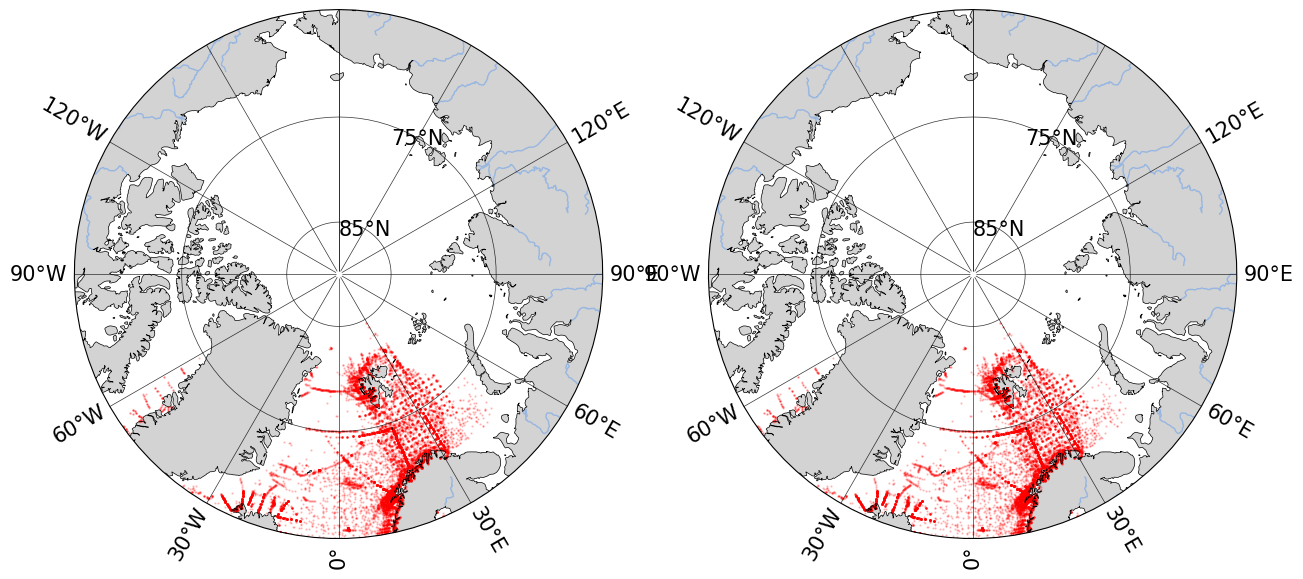

In [14]:
# import matplotlib.colors as mcolors
# import ArcTools as Atools
# f,ax = plt.subplots(1,2,figsize=[15,10],subplot_kw={'projection': ccrs.NorthPolarStereo()})
# ftz=15
# ax=ax.ravel()

# Atools.plot_arctic_ax_map_new(ax[0])


# ax[0].scatter(ds_temp.longitude,
#            ds_temp.latitude,
#            marker='.',transform=ccrs.PlateCarree(),s=2,color='red',label='ICES temp',alpha=0.2)


# Atools.plot_arctic_ax_map_new(ax[1])

# ax[1].scatter(ds_psal.longitude,
#            ds_psal.latitude,
#            marker='.',transform=ccrs.PlateCarree(),s=2,color='red',label='ICES psal',alpha=0.2)

In [15]:
# data_out = '/data0/user/aprigent/ICES/'
# ds_psal.to_netcdf(data_out+'ICES_ISAS_PSAL.nc')   
# ds_temp.to_netcdf(data_out+'ICES_ISAS_TEMP.nc')   


In [34]:
# ds_temp_test= xr.open_dataset(data_out+'ICES_ISAS_TEMP.nc')

In [4]:
# import glob
# import xarray as xr
# import numpy as np
# def concat_netcdf_psal(file_list):
#     ds = xr.open_dataset(file_list[0],decode_times=False)
#     param = ds.salinity.data

#     lon = ds.longitude.data
#     lat = ds.latitude.data
#     time = ds.time.data
#     depth = ds.depth.data
    
#     for f in file_list[1:]:
#         ds = xr.open_dataset(f,decode_times=False)
#         param = np.concatenate((param, ds.salinity.data),axis=0)
#         lon = np.concatenate((lon, ds.longitude.data),axis=0)
#         lat = np.concatenate((lat, ds.latitude.data),axis=0)
#         time = np.concatenate((time, ds.time.data),axis=0)
        
#     return param,lon,lat,time,depth

    
# def concat_netcdf_temp(file_list):
#     ds = xr.open_dataset(file_list[0],decode_times=False)
#     param = ds.temperature.data
#     lon = ds.longitude.data
#     lat = ds.latitude.data
#     time = ds.time.data
#     depth = ds.depth.data
    
#     for f in file_list[1:]:
#         ds = xr.open_dataset(f,decode_times=False)
#         param = np.concatenate((param, ds.temperature.data),axis=0)
#         lon = np.concatenate((lon, ds.longitude.data),axis=0)
#         lat = np.concatenate((lat, ds.latitude.data),axis=0)
#         time = np.concatenate((time, ds.time.data),axis=0)
        
#     return param,lon,lat,time,depth

# itp_path = '/data0/user/aprigent/ITP/'
# itp_list_psal = glob.glob(itp_path + '*ISAS_PSAL.nc')
# itp_list_temp = glob.glob(itp_path + '*ISAS_TEMP.nc')
# psal_itp,lon_itp_psal,lat_itp_psal,time_itp_psal, dep_psal = concat_netcdf_psal(itp_list_psal)
# temp_itp,lon_itp_temp,lat_itp_temp,time_itp_temp, dep_temp = concat_netcdf_temp(itp_list_temp)

In [ ]:
# time_itp_psal.min()
# from datetime import datetime, timedelta
# date_min = np.array([datetime.fromordinal(int(time_itp_psal.max()))])

In [14]:
date_min

array([datetime.datetime(2023, 7, 13, 0, 0)], dtype=object)